In [55]:
import pandas as pd
import numpy as np
import networkx as nx
import ast
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import spearmanr
from utils import projected_graph_custom, bipartite_graph, bipartite_projection, weighted_episode_rating
import graphs


ImportError: cannot import name 'weighted_episode_rating' from 'utils' (c:\Users\jose-\Desktop\Complex-Networks-and-One-Piece\utils.py)

Primero se genera el grafo bipartito con 2 conjuntos, personas y episodios. Un link entre una persona y episodio existe solo si esta trabajo en la produccion del capitulo.

In [ ]:
df = pd.read_csv("datasets/one_piece_merged.csv")
B = bipartite_graph(df)

Number of nodes: 1385, Number of edges: 5181


# Metricas y gráficos usando el grafo bipartito base

Componente gigante conexa

In [3]:
# Componentes conectadas

components = list(nx.connected_components(B))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)

Gcc = B.subgraph(largest_component).copy()

print("\nGiant Component")
print(f"Nodos: {Gcc.number_of_nodes()}")
print(f"Aristas: {Gcc.number_of_edges()}")

Componentes conectadas
Número de componentes: 4
Tamaño componente más grande: 1382

Giant Component
Nodos: 1382
Aristas: 5181


In [4]:
avg_path_length = nx.average_shortest_path_length(Gcc)

print("\nLargo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")


Largo de camino característico
Average shortest path length: 3.5644


Clustering coefficient
Average clustering coefficient: 0.0000
Top 10 clustering
ep_1: 0.0000
Junki Takegami: 0.0000
Tomoko Yoshida: 0.0000
Kazuya Hisada: 0.0000
Kōnosuke Uda: 0.0000
ep_2: 0.0000
Michiru Shimada: 0.0000
Miyuki Sato: 0.0000
Eisaku Inoue: 0.0000
Tetsuji Nakamura: 0.0000


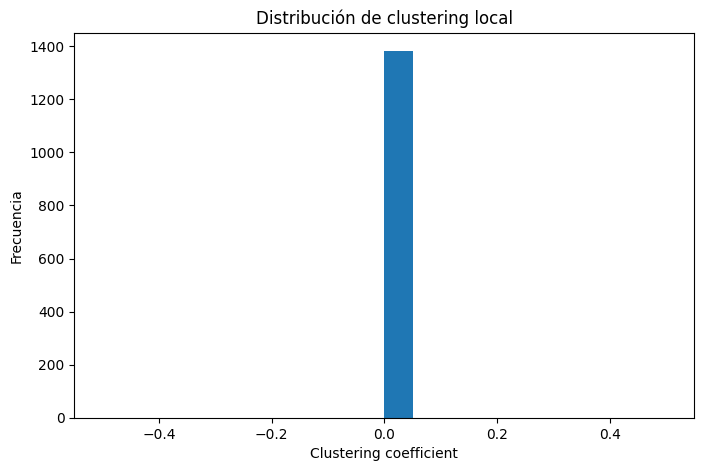

In [5]:
# Coeficiente de clustering

avg_clustering = nx.average_clustering(Gcc)

print("Clustering coefficient")
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# Clustering por nodo

clustering_per_node = nx.clustering(Gcc)

# top 10 directores
top_clustering = sorted(
    clustering_per_node.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 clustering")

for node, coeff in top_clustering:

    director_name = node.replace("director_", "")

    print(f"{director_name}: {coeff:.4f}")

# Distribucion

clustering_values = list(clustering_per_node.values())

plt.figure(figsize=(8,5))

plt.hist(clustering_values, bins=20)

plt.xlabel("Clustering coefficient")
plt.ylabel("Frecuencia")
plt.title("Distribución de clustering local")

plt.show()

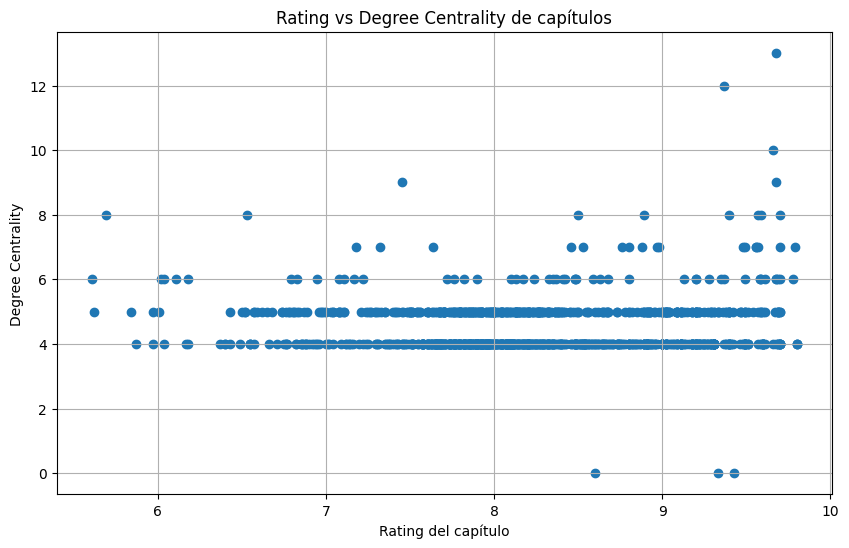

In [6]:
# degree centrality
degree_centrality_bipartite = B.degree()

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(degree_centrality_bipartite[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Degree Centrality")
plt.title("Rating vs Degree Centrality de capítulos")

plt.grid(True)

plt.show()

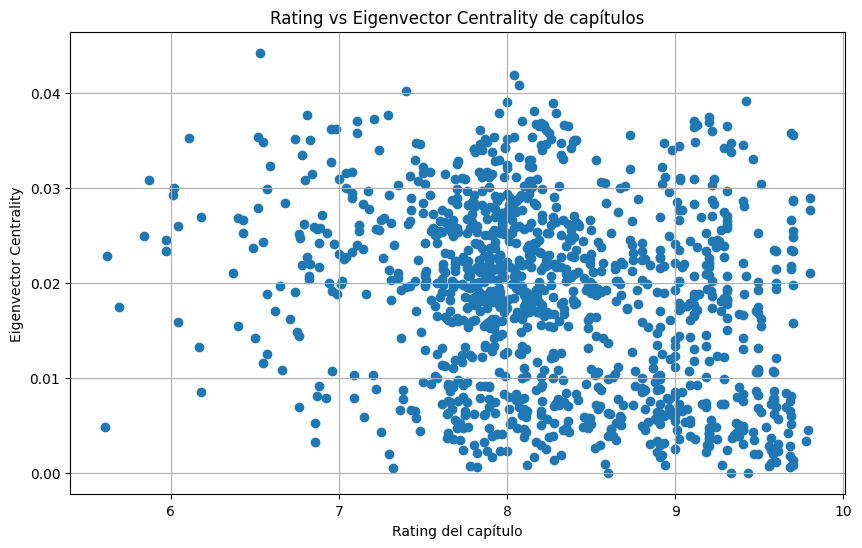

In [7]:
# Eigenvector centrality
eigenvector_centrality_bipartite = nx.eigenvector_centrality(B, max_iter=1000,  weight='weight')

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(eigenvector_centrality_bipartite[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Eigenvector Centrality")
plt.title("Rating vs Eigenvector Centrality de capítulos")

plt.grid(True)

plt.show()

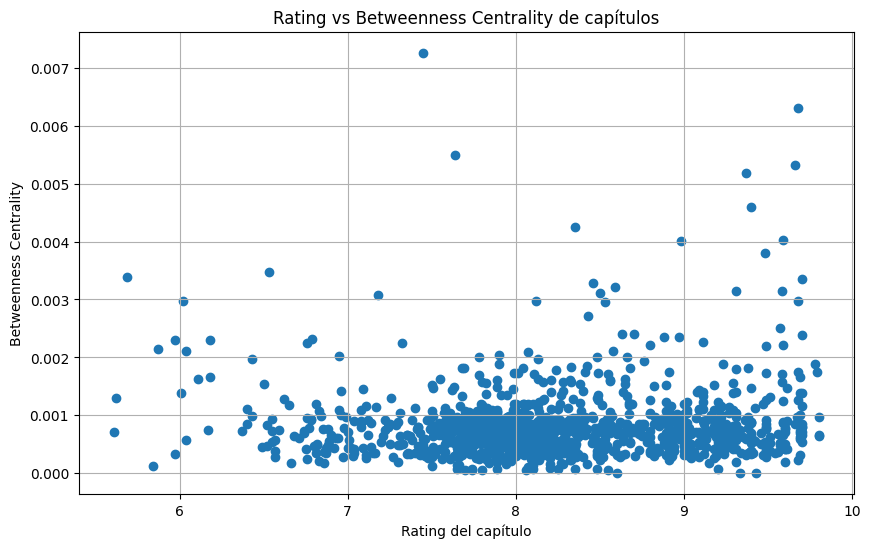

In [8]:
# Eigenvector centrality
betweenness_bipartite = nx.betweenness_centrality(B)

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(betweenness_bipartite[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Betweenness Centrality")
plt.title("Rating vs Betweenness Centrality de capítulos")

plt.grid(True)

plt.show()

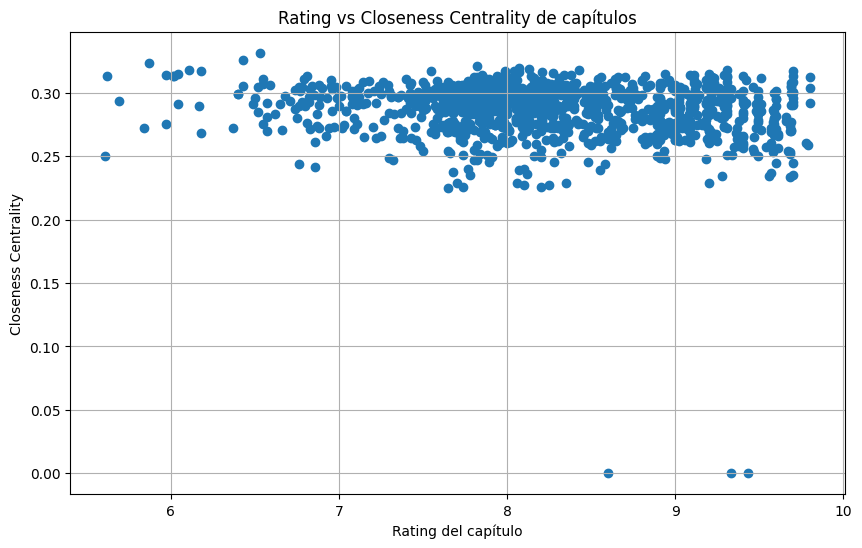

In [9]:
# Eigenvector centrality
closeness_bipartite = nx.closeness_centrality(B)

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(closeness_bipartite[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Closeness Centrality")
plt.title("Rating vs Closeness Centrality de capítulos")

plt.grid(True)

plt.show()

# Metricas sobre la proyección bipartita usando NetworkX vanilla

Se procede a sacar la proyeccion del grafo, haciendo que solo queden las personas del staff.

In [10]:
G_staff = bipartite_projection(B, "staff")

Number of nodes: 234, Number of edges: 2878


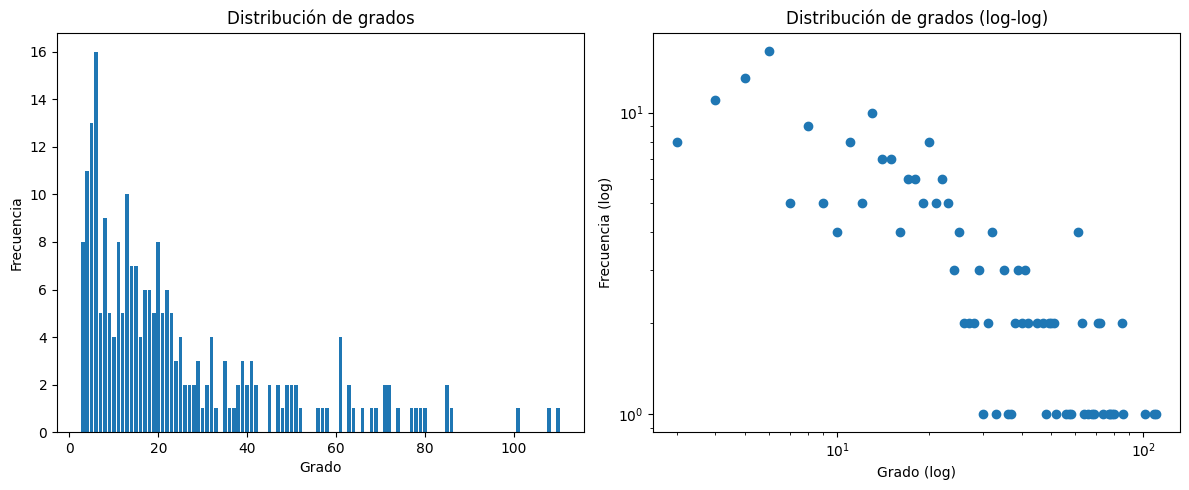

Estadísticas de grado
Número de nodos: 234
Número de aristas: 2878
Grado promedio: 24.60
Grado mediano: 17.00
Grado máximo: 110
Grado mínimo: 3
Desviación estándar: 22.16


In [11]:
# distribucion de grados

degrees = [deg for _, deg in G_staff.degree()]

# conteo de frecuencias
degree_counts = Counter(degrees)

x = sorted(degree_counts.keys())
y = [degree_counts[k] for k in x]

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.bar(x, y)

plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.title("Distribución de grados")


# Plot log-log
plt.subplot(1, 2, 2)

plt.scatter(x, y)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Grado (log)")
plt.ylabel("Frecuencia (log)")
plt.title("Distribución de grados (log-log)")

plt.tight_layout()
plt.show()

print("Estadísticas de grado")
print(f"Número de nodos: {G_staff.number_of_nodes()}")
print(f"Número de aristas: {G_staff.number_of_edges()}")

print(f"Grado promedio: {np.mean(degrees):.2f}")
print(f"Grado mediano: {np.median(degrees):.2f}")
print(f"Grado máximo: {np.max(degrees)}")
print(f"Grado mínimo: {np.min(degrees)}")
print(f"Desviación estándar: {np.std(degrees):.2f}")

In [12]:
# Componentes conectadas

components = list(nx.connected_components(G_staff))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)


print("Giant Component")
print(f"Nodos: {G_staff.number_of_nodes()}")
print(f"Aristas: {G_staff.number_of_edges()}")

Componentes conectadas
Número de componentes: 1
Tamaño componente más grande: 234
Giant Component
Nodos: 234
Aristas: 2878


In [13]:
avg_path_length = nx.average_shortest_path_length(G_staff)

print("Largo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")

Largo de camino característico
Average shortest path length: 2.1649


Clustering coefficient
Average clustering coefficient: 0.6627
Top 10 clustering
Ryō Ōnishi: 1.0000
Toru Yamada: 1.0000
Majiro: 1.0000
Zhenlei Cheng: 1.0000
Fujī Rina: 1.0000
Evereux{Assistant}: 1.0000
Takaaki Ishiyama: 1.0000
Satohiko Sano: 1.0000
Kiichi Suzuno: 1.0000
Mami Kotoku: 1.0000


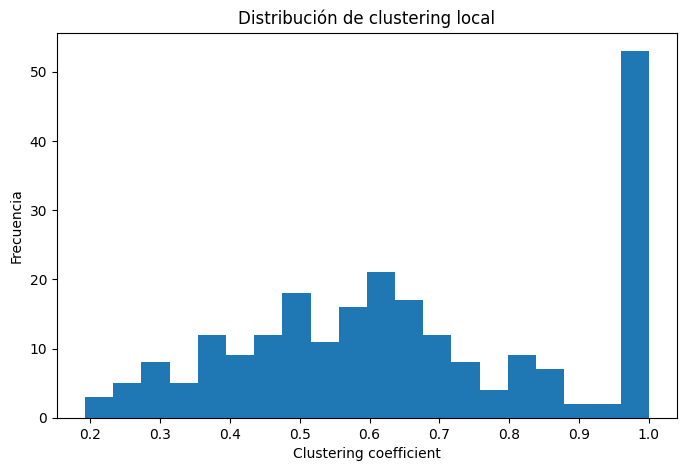

In [14]:
# coeficiente de clustering

avg_clustering = nx.average_clustering(G_staff)

print("Clustering coefficient")
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# por nodo

clustering_per_node = nx.clustering(G_staff)

# top 10 directores
top_clustering = sorted(
    clustering_per_node.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 clustering")

for node, coeff in top_clustering:

    director_name = node.replace("director_", "")

    print(f"{director_name}: {coeff:.4f}")

# Distribucion

clustering_values = list(clustering_per_node.values())

plt.figure(figsize=(8,5))

plt.hist(clustering_values, bins=20)

plt.xlabel("Clustering coefficient")
plt.ylabel("Frecuencia")
plt.title("Distribución de clustering local")

plt.show()

Centralidad de grado

In [15]:
degree_centrality_nx = dict(G_staff.degree())

top = sorted(degree_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 110
Jin Tanaka 108
Kenji Yokoyama 101
Miyuki Sato 86
Masayuki Takagi 85
Atsuhiro Tomioka 85
Miho Shiraishi 80
Eisaku Inoue 79
Masahiro Shimanuki 78
Shōji Yonemura 77


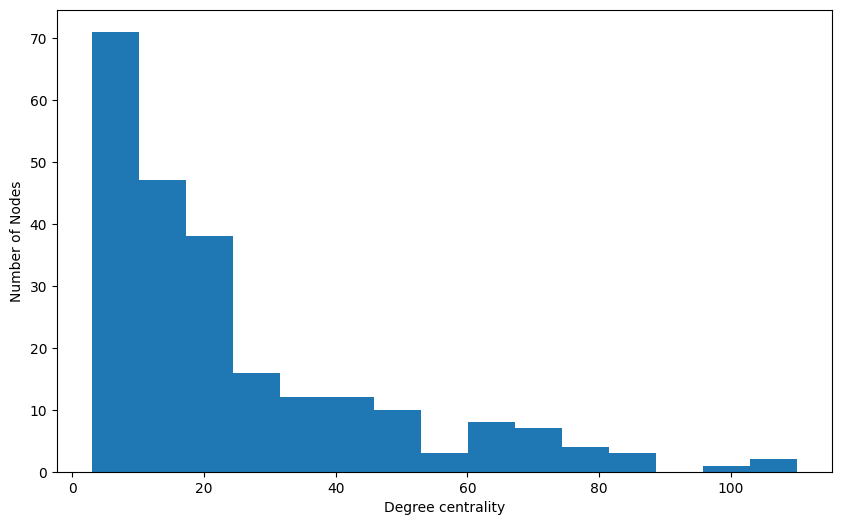

In [16]:
# Separar datos
personas = list(degree_centrality_nx.keys())
grados = list(degree_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Degree centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Centralidad de grado normalizada

In [17]:
degree = nx.degree_centrality(G_staff)

top = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 0.4721030042918455
Jin Tanaka 0.463519313304721
Kenji Yokoyama 0.4334763948497854
Miyuki Sato 0.36909871244635195
Masayuki Takagi 0.3648068669527897
Atsuhiro Tomioka 0.3648068669527897
Miho Shiraishi 0.34334763948497854
Eisaku Inoue 0.33905579399141633
Masahiro Shimanuki 0.33476394849785407
Shōji Yonemura 0.33047210300429186


Eigenvector centrality sin considerar peso de la arista

In [18]:
eigen = nx.eigenvector_centrality(G_staff)

top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Kazuya Hisada 0.1853056667758415
Kenji Yokoyama 0.18212953002554003
Jin Tanaka 0.17417102977117171
Masahiro Shimanuki 0.15853813049190457
Toshio Deguchi 0.1542213883895502
Atsuhiro Tomioka 0.15204234815368914
Masayuki Takagi 0.15113270826558198
Miho Shiraishi 0.14623984844398807
Eisaku Inoue 0.1447070229821218
Tomohiro Nakayama 0.14433643451369546


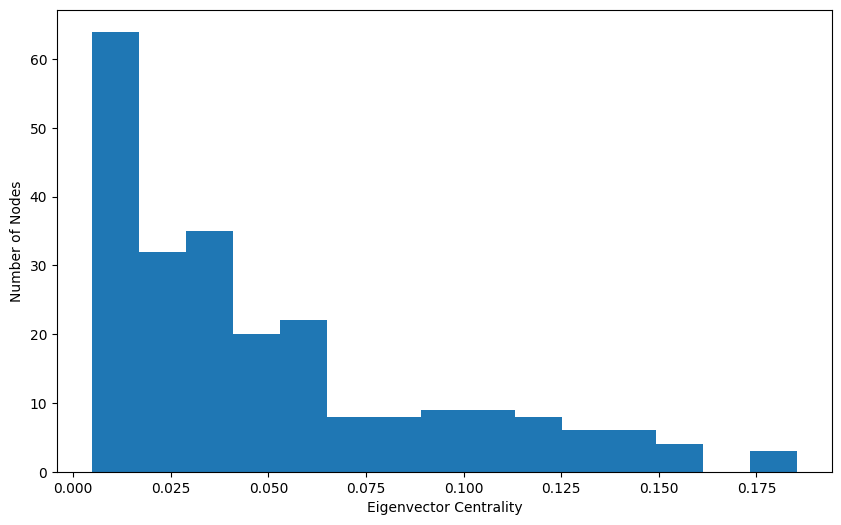

In [19]:
# Separar datos
personas = list(eigen.keys())
grados = list(eigen.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Eigenvector centrality considerando el peso de la arista

In [20]:
eigenvector_centrality_nx = nx.eigenvector_centrality(G_staff, weight='weight')

top_eigen = sorted(eigenvector_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Miyuki Sato 0.4042984433731154
Hirohiko Kamisaka 0.30836616883626644
Miho Shiraishi 0.30807424281980966
Ryūji Yoshiike 0.2724313422107723
Yoshiyuki Suga 0.24571620285639875
Kenji Yokoyama 0.21806762383595651
Masayuki Takagi 0.19880187226203194
Jin Tanaka 0.1967998848620236
Yoshihiro Ueda 0.1856794152011002
Michiyo Kawasaki 0.17646120762218126


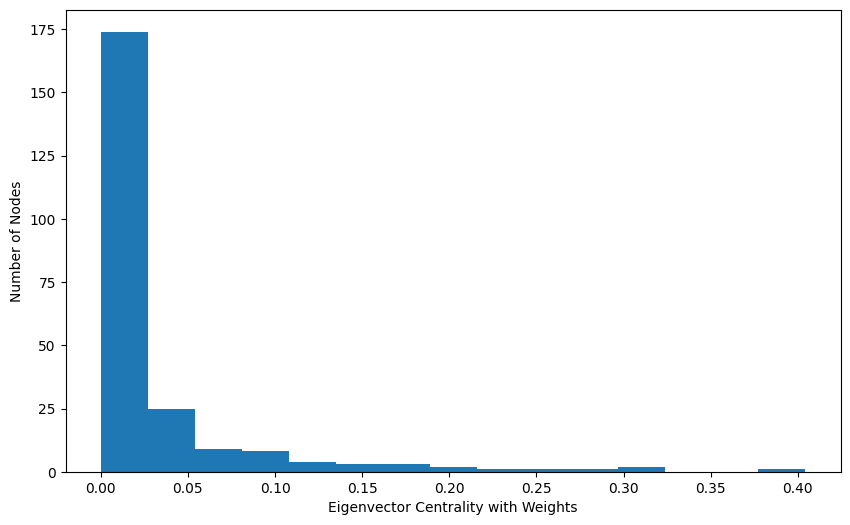

In [21]:
# Separar datos
personas = list(eigenvector_centrality_nx.keys())
grados = list(eigenvector_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality with Weights")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Closeness

In [22]:
closeness_centrality_nx = nx.closeness_centrality(G_staff)

top_closeness = sorted(closeness_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_closeness:
    print(name, val)

Kazuya Hisada 0.6544943820224719
Jin Tanaka 0.6508379888268156
Kenji Yokoyama 0.6383561643835617
Masayuki Takagi 0.6115485564304461
Eisaku Inoue 0.6005154639175257
Masahiro Shimanuki 0.6005154639175257
Miho Shiraishi 0.5974358974358974
Atsuhiro Tomioka 0.5943877551020408
Miyuki Sato 0.5913705583756346
Toshio Deguchi 0.5913705583756346


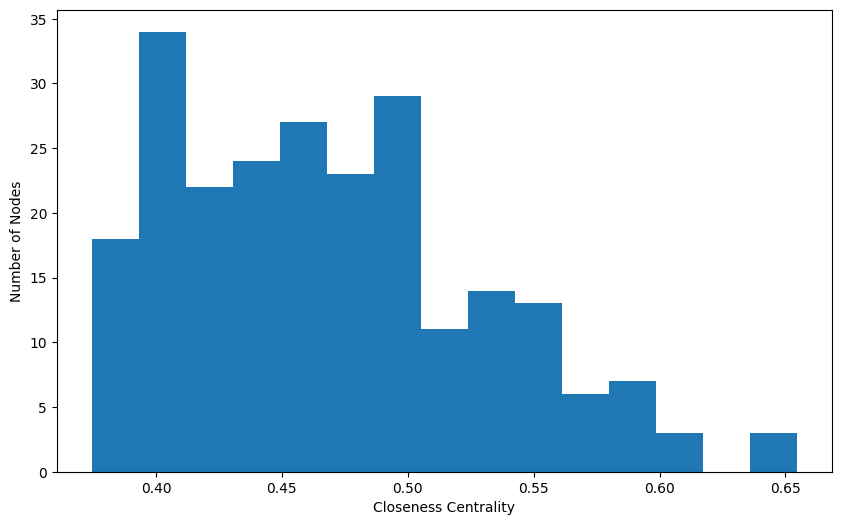

In [23]:
# Separar datos
personas = list(closeness_centrality_nx.keys())
grados = list(closeness_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Betwenness

In [24]:
betweenness_centrality_nx = nx.betweenness_centrality(G_staff)

top_betweenness = sorted(betweenness_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_betweenness:
    print(name, val)

Jin Tanaka 0.09633378873682834
Kazuya Hisada 0.092275936701012
Miyuki Sato 0.06822647240279536
Kenji Yokoyama 0.056882063067311014
Eisaku Inoue 0.03927594467125317
Masayuki Takagi 0.037859808088085596
Masahiro Kitazaki 0.03661422610620597
Atsuhiro Tomioka 0.035113169319852706
Masahiro Shimanuki 0.02931273023719063
Hirohiko Kamisaka 0.029090178627029395


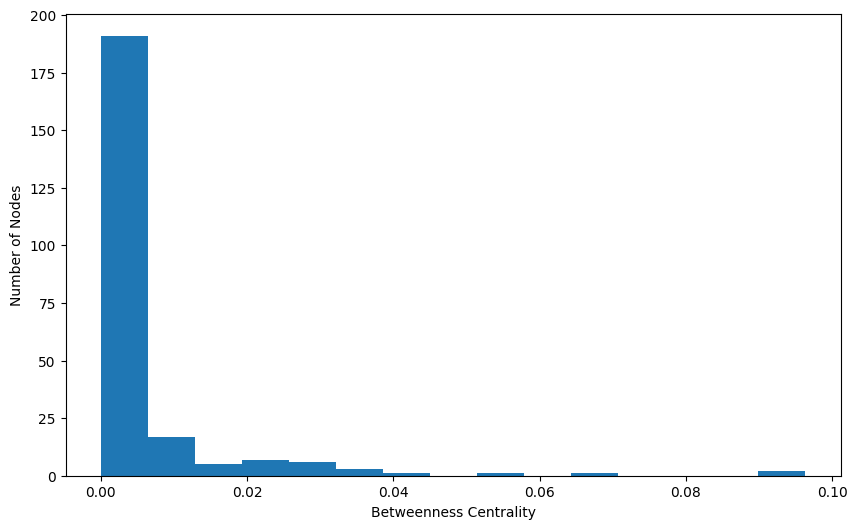

In [25]:
# Separar datos
personas = list(betweenness_centrality_nx.keys())
grados = list(betweenness_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

# Proyección Bipartita Personalizada con attributos ponderados

In [26]:
# Obtener nodos de staff
staff_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}

# Proyección
G_staff_custom = projected_graph_custom(B, staff_nodes, multigraph=False)

print(f"Number of nodes: {G_staff_custom.number_of_nodes()}, Number of edges: {G_staff_custom.number_of_edges()}")
nx.write_gexf(G_staff_custom, "one_piece_staff_projection_custom.gexf")

Number of nodes: 234, Number of edges: 2878


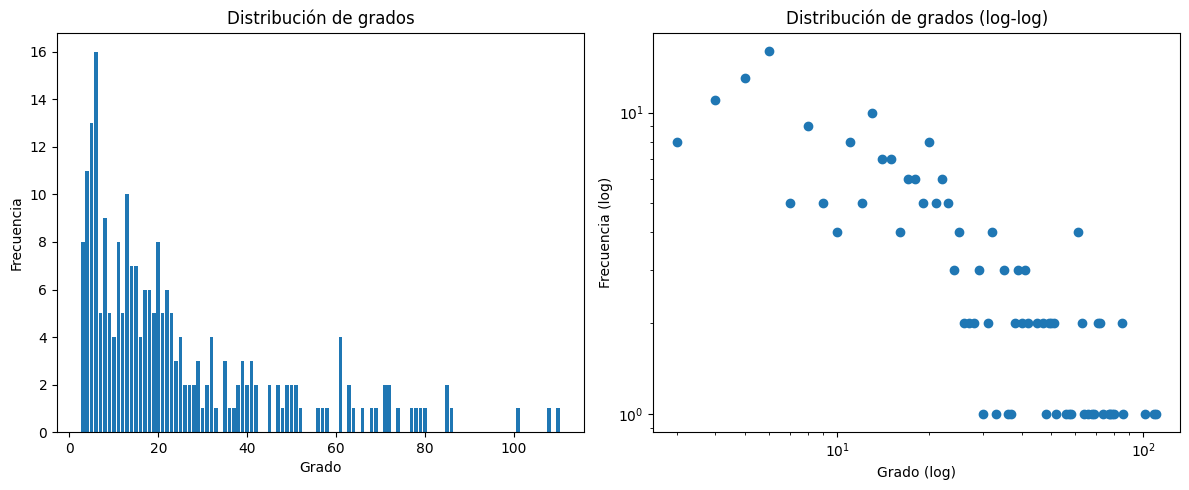

Estadísticas de grado
Número de nodos: 234
Número de aristas: 2878
Grado promedio: 24.60
Grado mediano: 17.00
Grado máximo: 110
Grado mínimo: 3
Desviación estándar: 22.16


In [27]:
# distribucion de grados

degrees = [deg for _, deg in G_staff_custom.degree()]

# conteo de frecuencias
degree_counts = Counter(degrees)

x = sorted(degree_counts.keys())
y = [degree_counts[k] for k in x]

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.bar(x, y)

plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.title("Distribución de grados")


# Plot log-log
plt.subplot(1, 2, 2)

plt.scatter(x, y)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Grado (log)")
plt.ylabel("Frecuencia (log)")
plt.title("Distribución de grados (log-log)")

plt.tight_layout()
plt.show()

print("Estadísticas de grado")
print(f"Número de nodos: {G_staff_custom.number_of_nodes()}")
print(f"Número de aristas: {G_staff_custom.number_of_edges()}")

print(f"Grado promedio: {np.mean(degrees):.2f}")
print(f"Grado mediano: {np.median(degrees):.2f}")
print(f"Grado máximo: {np.max(degrees)}")
print(f"Grado mínimo: {np.min(degrees)}")
print(f"Desviación estándar: {np.std(degrees):.2f}")

In [28]:
# Componentes conectadas

components = list(nx.connected_components(G_staff_custom))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)


print("Giant Component")
print(f"Nodos: {G_staff_custom.number_of_nodes()}")
print(f"Aristas: {G_staff_custom.number_of_edges()}")

Componentes conectadas
Número de componentes: 1
Tamaño componente más grande: 234
Giant Component
Nodos: 234
Aristas: 2878


In [29]:
avg_path_length = nx.average_shortest_path_length(G_staff_custom)

print("Largo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")

Largo de camino característico
Average shortest path length: 2.1649


Clustering coefficient
Average clustering coefficient: 0.6627
Top 10 clustering
Ryō Ōnishi: 1.0000
Toru Yamada: 1.0000
Majiro: 1.0000
Zhenlei Cheng: 1.0000
Fujī Rina: 1.0000
Evereux{Assistant}: 1.0000
Takaaki Ishiyama: 1.0000
Satohiko Sano: 1.0000
Kiichi Suzuno: 1.0000
Mami Kotoku: 1.0000


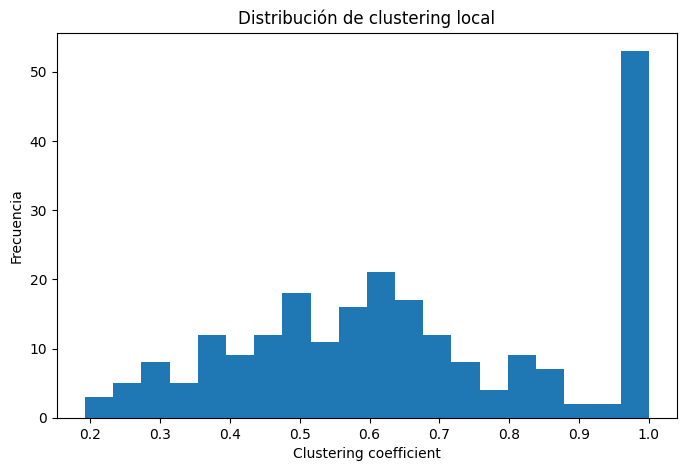

In [30]:
# coeficiente de clustering

avg_clustering = nx.average_clustering(G_staff_custom)

print("Clustering coefficient")
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# por nodo

clustering_per_node = nx.clustering(G_staff_custom)

# top 10 directores
top_clustering = sorted(
    clustering_per_node.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 clustering")

for node, coeff in top_clustering:

    director_name = node.replace("director_", "")

    print(f"{director_name}: {coeff:.4f}")

# Distribucion

clustering_values = list(clustering_per_node.values())

plt.figure(figsize=(8,5))

plt.hist(clustering_values, bins=20)

plt.xlabel("Clustering coefficient")
plt.ylabel("Frecuencia")
plt.title("Distribución de clustering local")

plt.show()

Centralidad de grado

In [31]:
degree_centrality_custom = dict(G_staff_custom.degree())

top = sorted(degree_centrality_custom.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 110
Jin Tanaka 108
Kenji Yokoyama 101
Miyuki Sato 86
Masayuki Takagi 85
Atsuhiro Tomioka 85
Miho Shiraishi 80
Eisaku Inoue 79
Masahiro Shimanuki 78
Shōji Yonemura 77


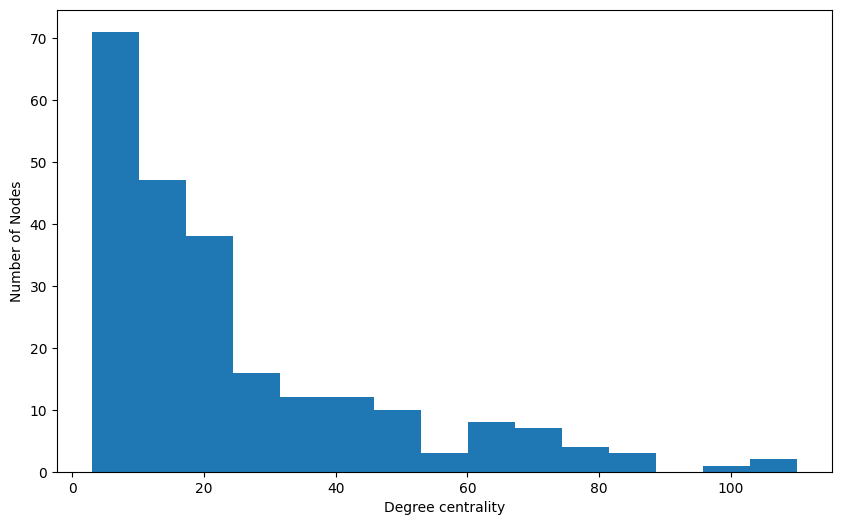

In [32]:
# Separar datos
personas = list(degree_centrality_custom.keys())
grados = list(degree_centrality_custom.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Degree centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Centralidad de grado normalizada

In [33]:
degree = nx.degree_centrality(G_staff_custom)

top = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 0.4721030042918455
Jin Tanaka 0.463519313304721
Kenji Yokoyama 0.4334763948497854
Miyuki Sato 0.36909871244635195
Masayuki Takagi 0.3648068669527897
Atsuhiro Tomioka 0.3648068669527897
Miho Shiraishi 0.34334763948497854
Eisaku Inoue 0.33905579399141633
Masahiro Shimanuki 0.33476394849785407
Shōji Yonemura 0.33047210300429186


Eigenvector centrality sin considerar peso de la arista

In [34]:
eigen = nx.eigenvector_centrality(G_staff_custom)

top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Kazuya Hisada 0.1853056667758415
Kenji Yokoyama 0.18212953002554003
Jin Tanaka 0.17417102977117171
Masahiro Shimanuki 0.15853813049190457
Toshio Deguchi 0.1542213883895502
Atsuhiro Tomioka 0.15204234815368914
Masayuki Takagi 0.15113270826558198
Miho Shiraishi 0.14623984844398807
Eisaku Inoue 0.1447070229821218
Tomohiro Nakayama 0.14433643451369546


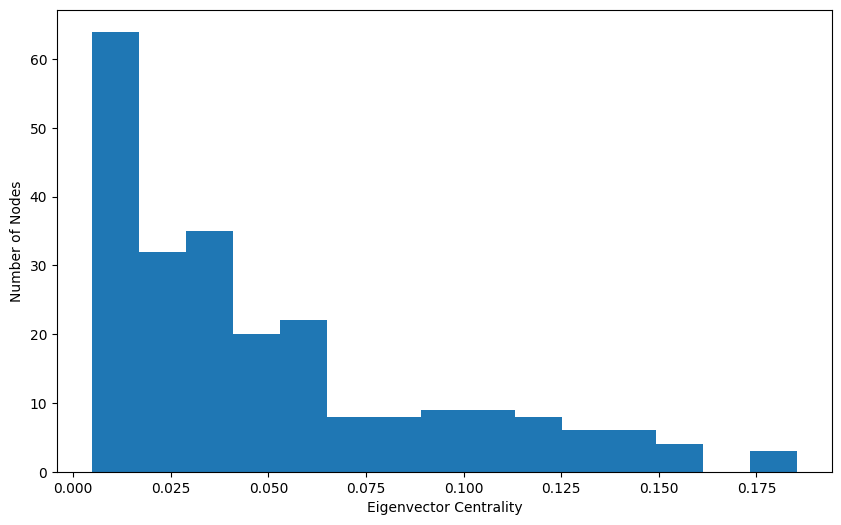

In [35]:
# Separar datos
personas = list(eigen.keys())
grados = list(eigen.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Eigenvector centrality considerando el peso de la arista

In [36]:
eigenvector_centrality_custom = nx.eigenvector_centrality(G_staff_custom, weight='rating')

top_eigen = sorted(eigenvector_centrality_custom.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Jin Tanaka 0.17996754871879145
Kazuya Hisada 0.17825529337612206
Kenji Yokoyama 0.16970382628319988
Atsuhiro Tomioka 0.15779823871235782
Toshio Deguchi 0.15775706309634974
Masahiro Shimanuki 0.15375029867941845
Kimitaka Itō 0.14777294240750774
Tomohiro Nakayama 0.14761997901584753
Shōji Yonemura 0.14760379039728905
Shigefumi Shingaki 0.1444879752162818


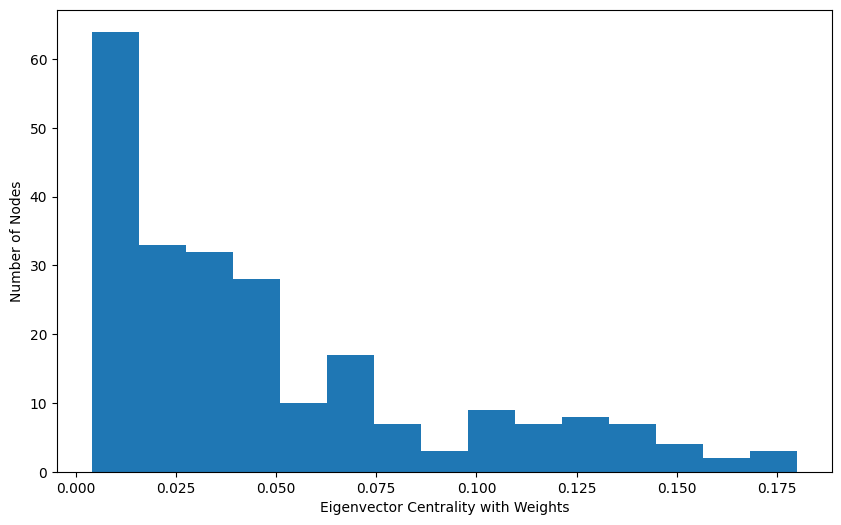

In [37]:
# Separar datos
personas = list(eigenvector_centrality_custom.keys())
grados = list(eigenvector_centrality_custom.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality with Weights")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Closeness

In [38]:
closeness_centrality_custom = nx.closeness_centrality(G_staff_custom)

top_closeness = sorted(closeness_centrality_custom.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_closeness:
    print(name, val)

Kazuya Hisada 0.6544943820224719
Jin Tanaka 0.6508379888268156
Kenji Yokoyama 0.6383561643835617
Masayuki Takagi 0.6115485564304461
Eisaku Inoue 0.6005154639175257
Masahiro Shimanuki 0.6005154639175257
Miho Shiraishi 0.5974358974358974
Atsuhiro Tomioka 0.5943877551020408
Miyuki Sato 0.5913705583756346
Toshio Deguchi 0.5913705583756346


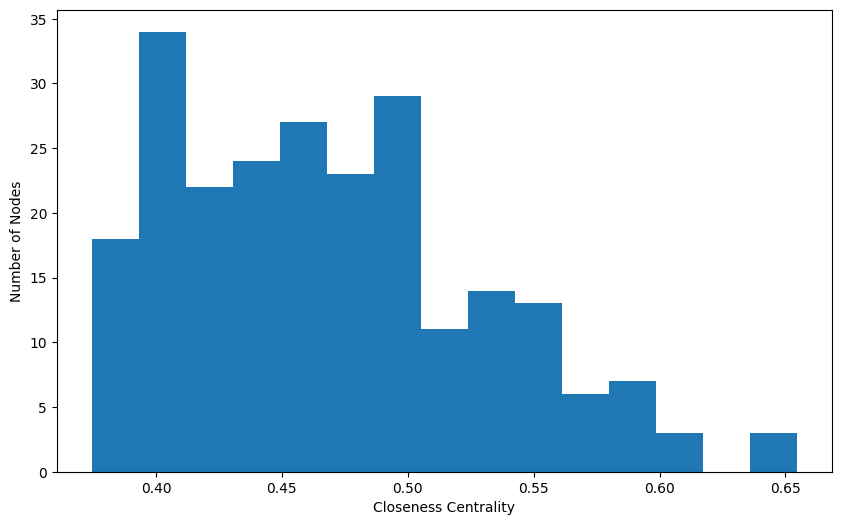

In [39]:
# Separar datos
personas = list(closeness_centrality_custom.keys())
grados = list(closeness_centrality_custom.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Betwenness

In [40]:
betweenness_centrality_custom = nx.betweenness_centrality(G_staff_custom)

top_betweenness = sorted(betweenness_centrality_custom.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_betweenness:
    print(name, val)

Jin Tanaka 0.09633378873682834
Kazuya Hisada 0.092275936701012
Miyuki Sato 0.06822647240279536
Kenji Yokoyama 0.05688206306731101
Eisaku Inoue 0.039275944671253164
Masayuki Takagi 0.037859808088085596
Masahiro Kitazaki 0.03661422610620596
Atsuhiro Tomioka 0.035113169319852706
Masahiro Shimanuki 0.02931273023719063
Hirohiko Kamisaka 0.029090178627029395


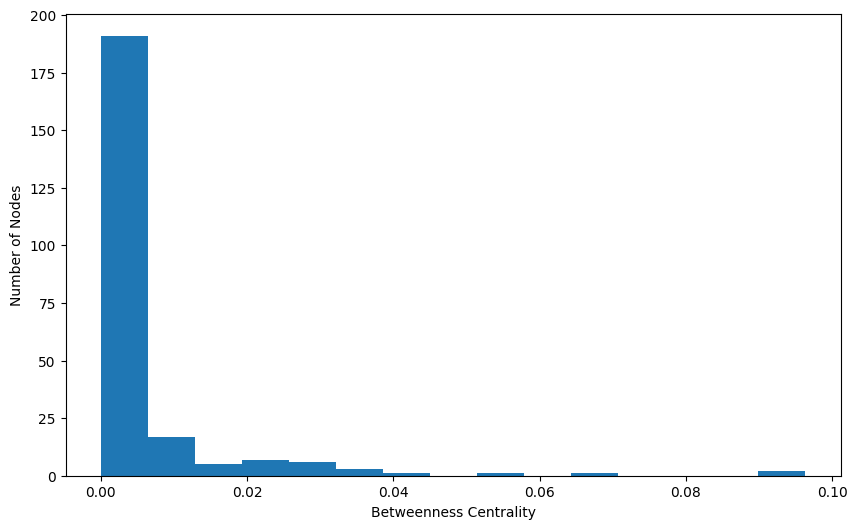

In [41]:
# Separar datos
personas = list(betweenness_centrality_custom.keys())
grados = list(betweenness_centrality_custom.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

# Proyección Bipartita Personalizada con attributos ponderados

In [42]:
from utils import projected_graph_custom
# Obtener nodos de staff
staff_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}

# Proyección
G_staff_custom_multi = projected_graph_custom(B, staff_nodes, multigraph=True)

print(f"Number of nodes: {G_staff_custom_multi.number_of_nodes()}, Number of edges: {G_staff_custom_multi.number_of_edges()}")
nx.write_gexf(G_staff_custom_multi, "one_piece_staff_projection_custom_multigraph.gexf")

Number of nodes: 234, Number of edges: 9490


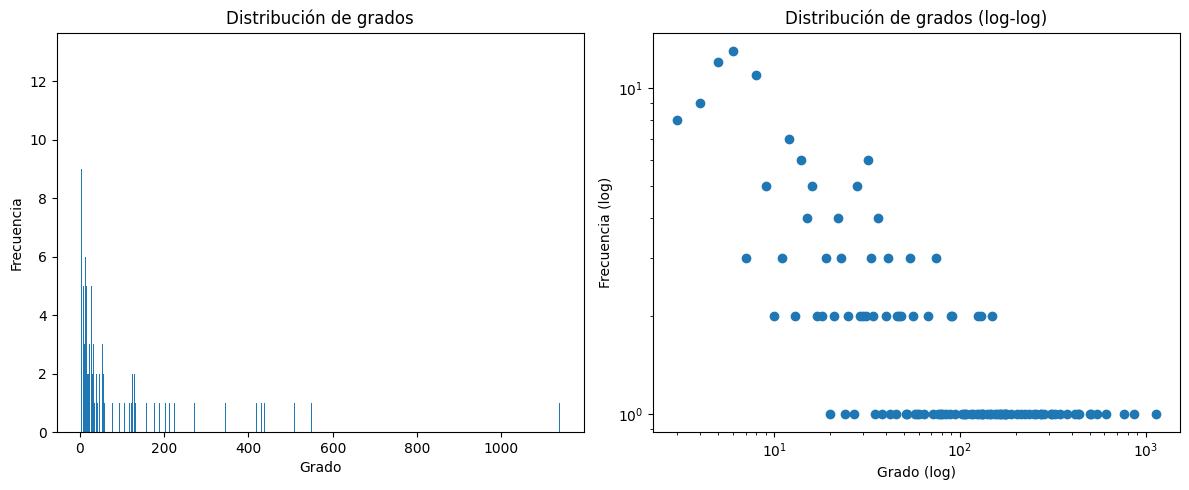

Estadísticas de grado
Número de nodos: 234
Número de aristas: 2878
Grado promedio: 81.11
Grado mediano: 29.00
Grado máximo: 1138
Grado mínimo: 3
Desviación estándar: 142.71


In [43]:
# distribucion de grados

degrees = [deg for _, deg in G_staff_custom_multi.degree()]

# conteo de frecuencias
degree_counts = Counter(degrees)

x = sorted(degree_counts.keys())
y = [degree_counts[k] for k in x]

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.bar(x, y)

plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.title("Distribución de grados")


# Plot log-log
plt.subplot(1, 2, 2)

plt.scatter(x, y)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Grado (log)")
plt.ylabel("Frecuencia (log)")
plt.title("Distribución de grados (log-log)")

plt.tight_layout()
plt.show()

print("Estadísticas de grado")
print(f"Número de nodos: {G_staff.number_of_nodes()}")
print(f"Número de aristas: {G_staff.number_of_edges()}")

print(f"Grado promedio: {np.mean(degrees):.2f}")
print(f"Grado mediano: {np.median(degrees):.2f}")
print(f"Grado máximo: {np.max(degrees)}")
print(f"Grado mínimo: {np.min(degrees)}")
print(f"Desviación estándar: {np.std(degrees):.2f}")

In [44]:
# Componentes conectadas

components = list(nx.connected_components(G_staff_custom_multi))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)


print("Giant Component")
print(f"Nodos: {G_staff_custom_multi.number_of_nodes()}")
print(f"Aristas: {G_staff_custom_multi.number_of_edges()}")

Componentes conectadas
Número de componentes: 1
Tamaño componente más grande: 234
Giant Component
Nodos: 234
Aristas: 9490


In [45]:
avg_path_length = nx.average_shortest_path_length(G_staff_custom_multi)

print("Largo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")

Largo de camino característico
Average shortest path length: 2.1649


Centralidad de grado

In [46]:
degree_centrality_custom_multi = dict(G_staff_custom_multi.degree())

top = sorted(degree_centrality_custom_multi.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Miyuki Sato 1138
Miho Shiraishi 861
Ryūji Yoshiike 765
Hirohiko Kamisaka 610
Jin Tanaka 550
Kenji Yokoyama 509
Yoshiyuki Suga 503
Masayuki Takagi 438
Tomohiro Nakayama 431
Kazuya Hisada 419


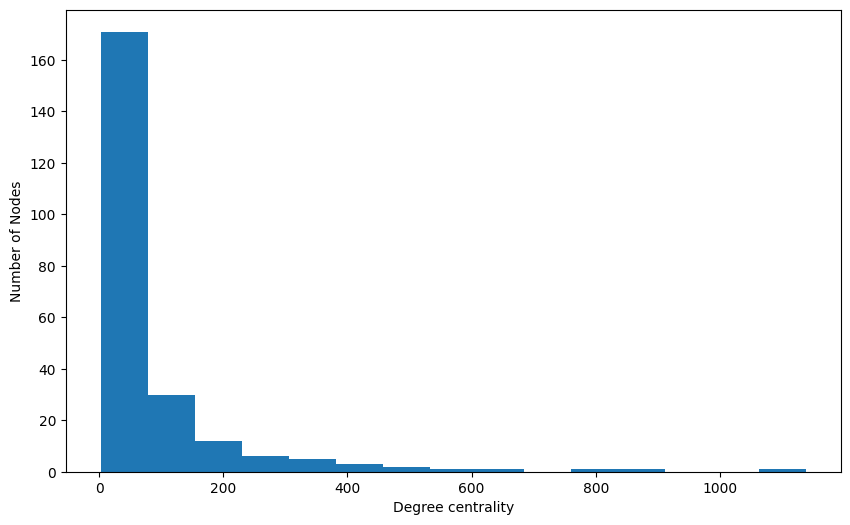

In [47]:
# Separar datos
personas = list(degree_centrality_custom_multi.keys())
grados = list(degree_centrality_custom_multi.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Degree centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Centralidad de grado normalizada

In [48]:
degree = nx.degree_centrality(G_staff_custom_multi)

top = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Miyuki Sato 4.884120171673819
Miho Shiraishi 3.6952789699570814
Ryūji Yoshiike 3.2832618025751072
Hirohiko Kamisaka 2.6180257510729614
Jin Tanaka 2.3605150214592276
Kenji Yokoyama 2.184549356223176
Yoshiyuki Suga 2.1587982832618025
Masayuki Takagi 1.8798283261802575
Tomohiro Nakayama 1.849785407725322
Kazuya Hisada 1.798283261802575


Closeness

In [49]:
closeness_centrality_custom_multi = nx.closeness_centrality(G_staff_custom_multi)

top_closeness = sorted(closeness_centrality_custom_multi.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_closeness:
    print(name, val)

Kazuya Hisada 0.6544943820224719
Jin Tanaka 0.6508379888268156
Kenji Yokoyama 0.6383561643835617
Masayuki Takagi 0.6115485564304461
Eisaku Inoue 0.6005154639175257
Masahiro Shimanuki 0.6005154639175257
Miho Shiraishi 0.5974358974358974
Atsuhiro Tomioka 0.5943877551020408
Miyuki Sato 0.5913705583756346
Toshio Deguchi 0.5913705583756346


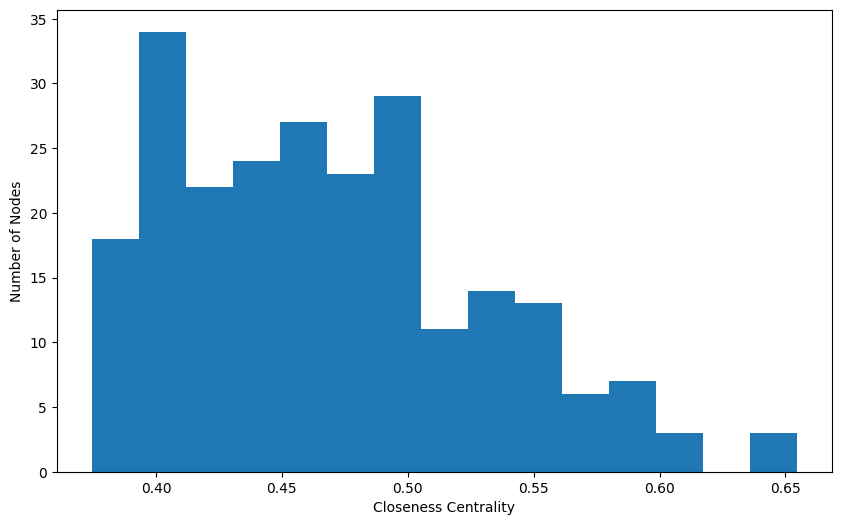

In [50]:
# Separar datos
personas = list(closeness_centrality_custom_multi.keys())
grados = list(closeness_centrality_custom_multi.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Betwenness

In [51]:
betweenness_centrality_custom_multi = nx.betweenness_centrality(G_staff_custom_multi)

top_betweenness = sorted(betweenness_centrality_custom_multi.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_betweenness:
    print(name, val)

Jin Tanaka 0.09633378873682834
Kazuya Hisada 0.092275936701012
Miyuki Sato 0.06822647240279536
Kenji Yokoyama 0.05688206306731101
Eisaku Inoue 0.039275944671253164
Masayuki Takagi 0.037859808088085596
Masahiro Kitazaki 0.03661422610620596
Atsuhiro Tomioka 0.035113169319852706
Masahiro Shimanuki 0.02931273023719063
Hirohiko Kamisaka 0.029090178627029395


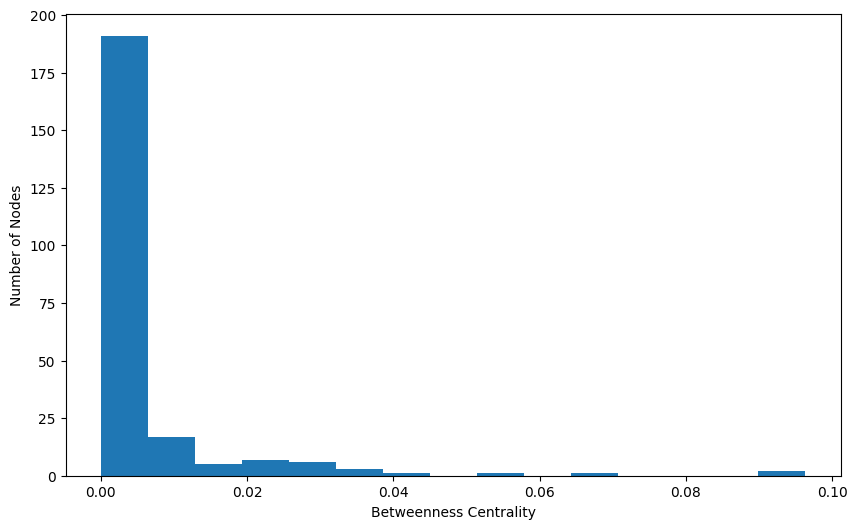

In [52]:
# Separar datos
personas = list(betweenness_centrality_custom_multi.keys())
grados = list(betweenness_centrality_custom_multi.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

# Spearman

In [54]:
director_rating = weighted_episode_rating(Gcc, df)

NameError: name 'weighted_episode_rating' is not defined

### Spearman para grafo bipartito

In [ ]:

centralities = {
    "Degree": dict(degree_centrality_bipartite),
    "Betweenness":  dict(betweenness_bipartite),
    "Closeness": dict(closeness_bipartite),
    "Eigenvector": dict(eigenvector_centrality_bipartite)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.034348144996084726 p=0.6011369673844529
Betweenness rho=0.10360012000068838 p=0.11398179074481966
Closeness rho=0.02123429987553897 p=0.7466048755504583
Eigenvector rho=-0.16622479449629818 p=0.01086917043799986


### Spearman para proyeccion de networkx

In [ ]:

centralities = {
    "Degree": dict(degree_centrality_nx),
    "Betweenness":  dict(betweenness_centrality_nx),
    "Closeness": dict(closeness_centrality_nx),
    "Eigenvector": dict(eigenvector_centrality_nx)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.23978301645292763 p=0.0002134915795767096
Betweenness rho=0.18632007504458215 p=0.004236776289772372
Closeness rho=0.24469092744128887 p=0.0001564261966581858
Eigenvector rho=-0.1348633045047017 p=0.03926574254488833


### Spearman para proyeccion personalizada ponderada

In [ ]:

centralities = {
    "Degree": dict(degree_centrality_custom),
    "Betweenness":  dict(betweenness_centrality_custom),
    "Closeness": dict(closeness_centrality_custom),
    "Eigenvector": dict(eigenvector_centrality_custom)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.23978301645292763 p=0.0002134915795767096
Betweenness rho=0.18632007504458215 p=0.004236776289772372
Closeness rho=0.24469092744128887 p=0.0001564261966581858
Eigenvector rho=0.4065423088220579 p=9.991739921040355e-11


### Spearman para proyeccion personalizada multigrafo

In [ ]:

centralities = {
    "Degree": dict(degree_centrality_custom_multi),
    "Betweenness":  dict(betweenness_centrality_custom_multi),
    "Closeness": dict(closeness_centrality_custom_multi)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.11881055109162389 p=0.06965457903491669
Betweenness rho=0.18632007504458215 p=0.004236776289772372
Closeness rho=0.24469092744128887 p=0.0001564261966581858


# Coeficiente de Mundo Pequeño

Hacemos nuestro propio caso para calcular el coeficiente de mundo pequeño, para comparar el coeficiente con las aproximaciones de un grafo ER equivalente.

In [ ]:
import math

def small_world_coeff(G):
    C = nx.transitivity(G)
    L = nx.average_shortest_path_length(G)

    n = 234
    edges = 2878
    k = (2 * edges) / n

    C_r = k / n
    L_r = math.log(n) / math.log(k)

    sw = (C / C_r) / (L / L_r)

    return sw

In [ ]:
small_world_2 = small_world_coeff(G_staff)

In [ ]:
small_world = nx.sigma(G_staff, niter = 10, nrand=5, seed=1)

#print(small_world)

In [ ]:
print(small_world)
print(small_world_2)

1.2863143303161462
2.800260612511658


# Evolución del metricas a lo largo del tiempo

Primero veremos la evolución del rating promedio a medida que fueron surgiendo más capitulos

Text(0.5, 1.0, 'Evolución del rating promedio a lo largo del tiempo')

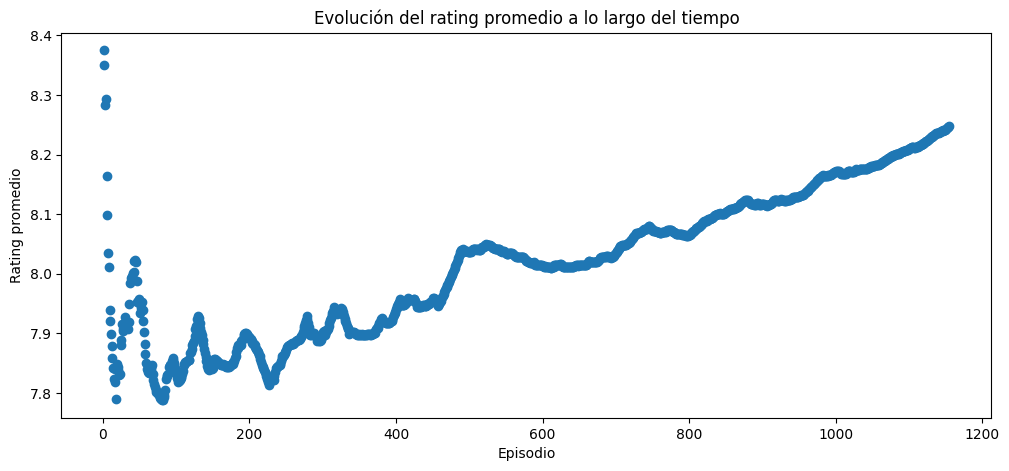

In [ ]:
r_total = 0
cantidad = 0
rating_promedio = []
for _, row in df.iterrows():
    r_total += row['rating']
    cantidad += 1
    rating_promedio.append(r_total/cantidad)

x = df['episodio']
y = rating_promedio

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Rating promedio")
plt.title("Evolución del rating promedio a lo largo del tiempo")

Evolución del grafo por capitulo (para calcular y almacenar las metricas)

In [ ]:
# Columnas donde hay listas de personas
staff_columns = ["guion", "arte", "animacion", "direccion"]
value_columns = ["n de paginas", "rating", "votos"]

# Igual a como se realizó inicialmente la generación del grafo, solo que con un paso extra entre medio
B = nx.Graph()
G_temp = nx.Graph()
staff_nodes_temp = {}

# Acá añadir las listas de metricas a almacenar a lo largo del tiempo
avg_closeness = []
avg_betweenness = []
avg_path_len = []
avg_degree_normalized = []
avg_degree = []

for _, row in df.iterrows():
    episodio = f"ep_{int(row['episodio'])}"
    
    B.add_node(episodio, bipartite="episode")

    value_dict = {}
    for val in value_columns:
        value_dict[val] = row[val]
    
    nx.set_node_attributes(B, {episodio: value_dict})

    for col in staff_columns:
        personas = parse_list(row[col])
        
        for persona in personas:
            persona_clean = persona.split("(")[0].strip()

            # Agregar nodo persona
            if persona_clean == '':
                continue
            B.add_node(persona_clean, bipartite="staff")

            # Agregar arista
            B.add_edge(persona_clean, episodio)
    
    staff_nodes_temp = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}
    G_prev = G_temp
    G_temp = projected_graph_custom(B, staff_nodes_temp)

    # Introducir metricas a calcular :)
    avg_closeness.append(np.mean(list(nx.closeness_centrality(G_temp).values())))
    if nx.connected.is_connected(G_temp):
        avg_path_len.append(nx.average_shortest_path_length(G_temp))
    else:
        avg_path_len.append(None)
    avg_degree_normalized.append(np.mean(list(nx.degree_centrality(G_temp).values())))
    avg_degree.append(np.mean(list(dict(G_temp.degree()).values())))
    avg_betweenness.append(np.mean(list(nx.betweenness_centrality(G_temp).values())))
    

Betweenness a lo largo del tiempo

Text(0.5, 1.0, 'Evolución de betweenness')

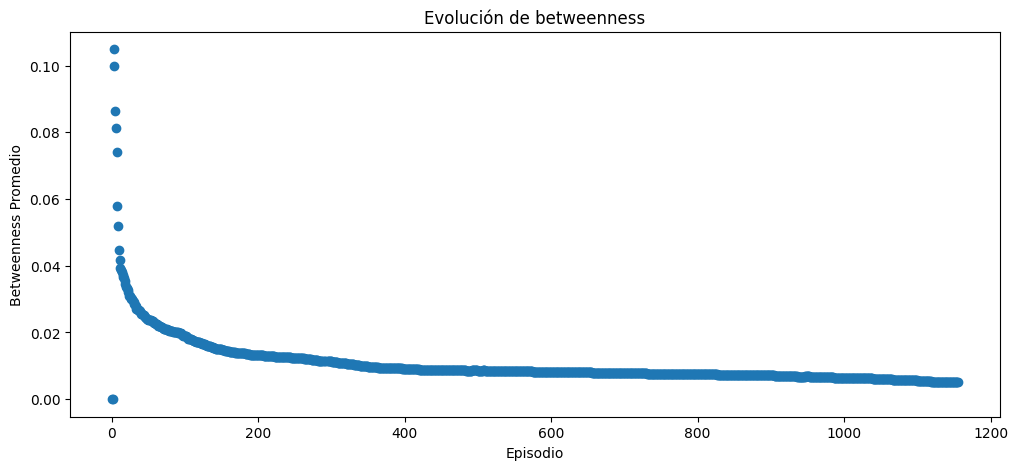

In [ ]:
y = avg_betweenness

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Betweenness Promedio")
plt.title("Evolución de betweenness")

Closeness a lo largo del tiempo

Text(0.5, 1.0, 'Evolución de Closeness')

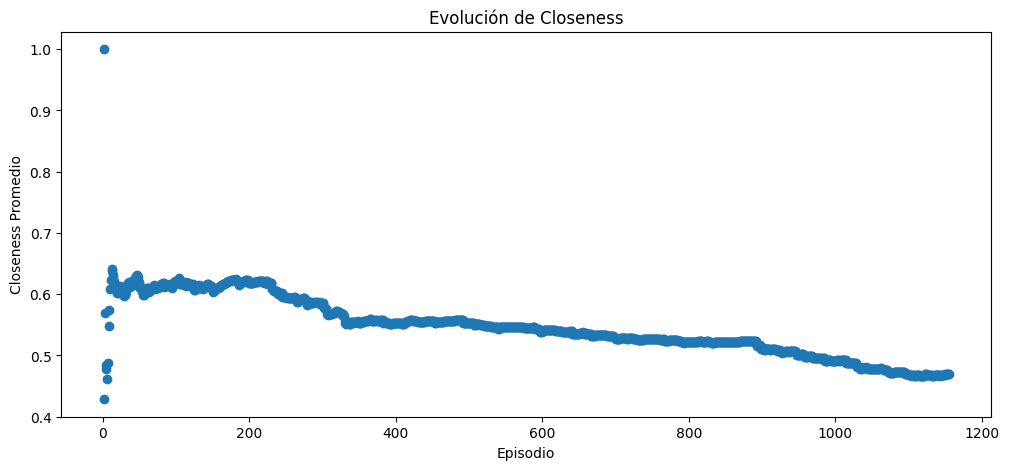

In [ ]:
y = avg_closeness

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Closeness Promedio")
plt.title("Evolución de Closeness")

Grado normalizado promedio a lo largo del tiempo

Text(0.5, 1.0, 'Evolución de grado normalizado')

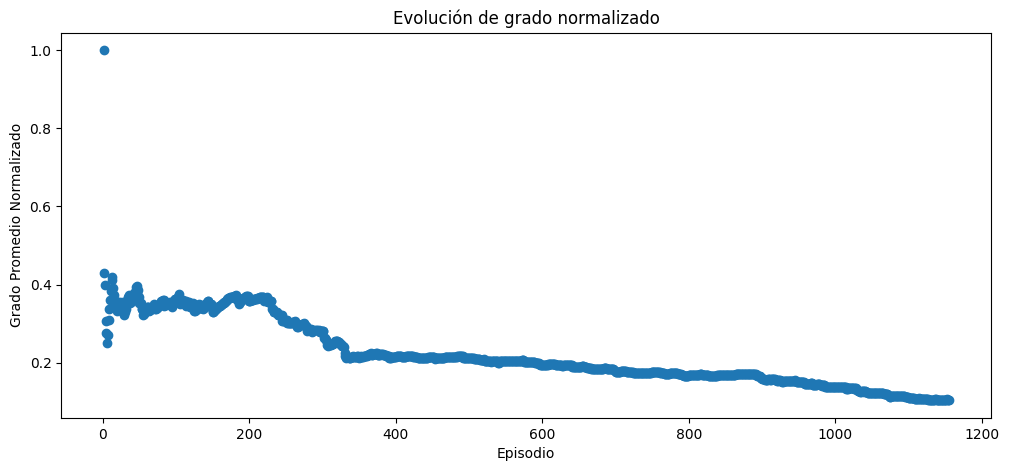

In [ ]:
y = avg_degree_normalized

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Grado Promedio Normalizado")
plt.title("Evolución de grado normalizado")

Grado promedio a lo largo del tiempo

Text(0.5, 1.0, 'Evolución de grado')

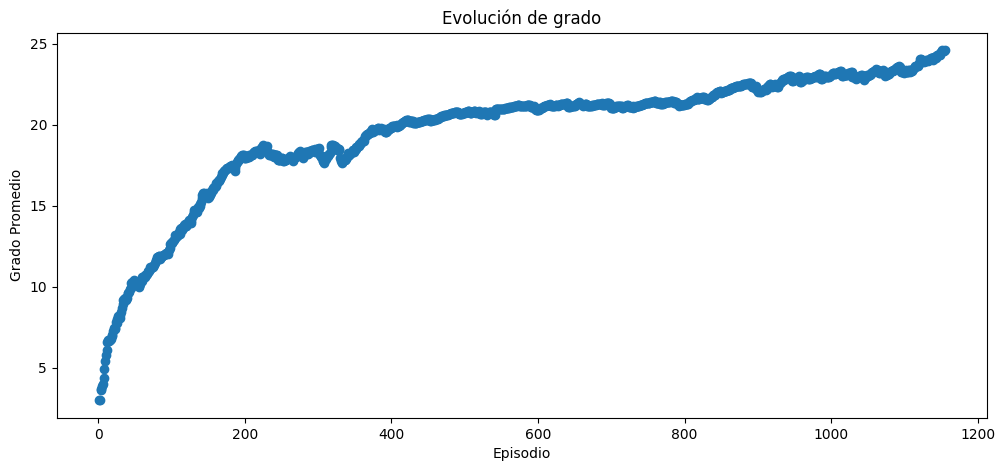

In [ ]:
y = avg_degree

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Grado Promedio")
plt.title("Evolución de grado")

Largo del camino caracteristico a lo largo del tiempo

Text(0.5, 1.0, 'Evolución del camino característico')

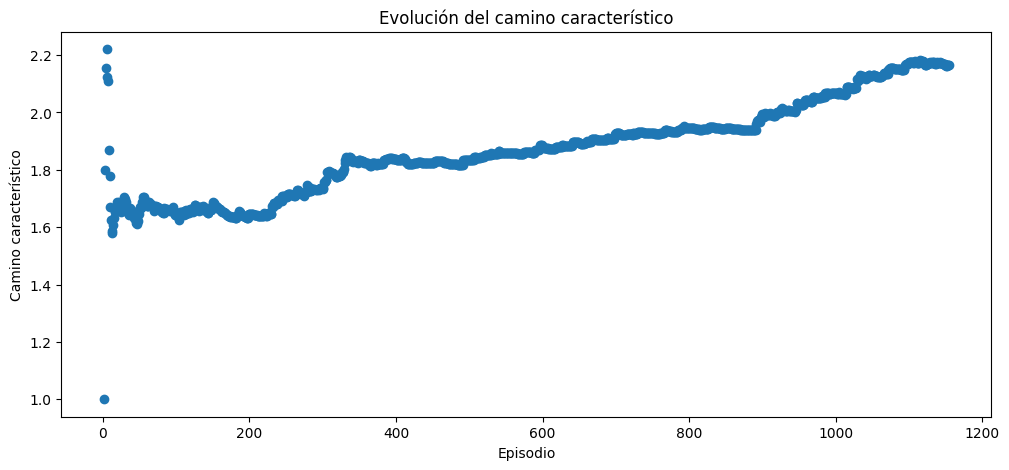

In [ ]:
y = avg_path_len

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Camino característico")
plt.title("Evolución del camino característico")